In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns

FIGURE_FACECOLOR = '#060606' # Dark Gray Background

# Font sizes
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE, family='sans-serif')
# Ensure text/axes elements are white/light for dark background
plt.rc('text', color='white')
plt.rc('axes', titlesize=MEDIUM_SIZE, labelcolor='white', edgecolor='white', titlecolor='white', facecolor='#363636') # Slightly lighter axes background
plt.rc('xtick', color='white', labelsize=SMALL_SIZE)
plt.rc('ytick', color='white', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE, facecolor='#404040', edgecolor='darkgray', labelcolor='white') # Style legend box
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor=FIGURE_FACECOLOR, edgecolor=FIGURE_FACECOLOR)

# Colormaps
PROB_CMAP = 'hot'
ENTROPY_CMAP = 'viridis' # Using viridis as it shows well on dark backgrounds

# --- Helper Function ---
def save_figure(fig, filename_base):
    """Saves the figure in PDF and PNG formats."""
    pdf_path = f"{filename_base}.pdf"
    png_path = f"{filename_base}.png"
    os.makedirs(os.path.dirname(filename_base), exist_ok=True)
    try:
        fig.savefig(pdf_path, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none', format='pdf')
        fig.savefig(png_path, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none', dpi=300, format='png')
        print(f"Saved {pdf_path} and {png_path}")
    except Exception as e:
        print(f"Error saving figure {filename_base}: {e}")

# --- Placeholder for Voxel-wise Entropy Function ---
# CRITICAL: Replace with your actual implementation
def entropy(data, apply_mean=True):
    try:
        p = np.clip(data, 1e-10, 1 - 1e-10)
        ent_values = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
        ent_values = np.nan_to_num(ent_values, nan=0.0)
        return np.mean(ent_values) if apply_mean else ent_values
    except Exception as e:
        print(f"Error in entropy calculation: {e}")
        return np.nan if apply_mean else np.zeros_like(data)

print("Setup for Figure 2 (Dark Gray, Centered CBars) complete.")

Setup for Figure 2 (Dark Gray, Centered CBars) complete.


In [14]:
subject_path = os.path.expanduser('~/Code/datasets/wmh/training/Utrecht/0')
output_dir = os.path.join("notebooks/main/figs/pdfs")
figure_basename = os.path.join(output_dir, "Figure2")

# Assumes runs_to_compare is defined globally or loaded previously
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
}
train_center_key = 'UtAmSi'

run_name_ce = runs_to_compare.get(f'CE {train_center_key}')
run_name_ce_meep = runs_to_compare.get(f'CE_MEEP {train_center_key}')
# --- End Configuration ---

# --- Load Data ---
# (This part is identical to the previous version - snipped for brevity)
# Ensure imgs_fig2 dictionary, header, and affine are populated here
print(f"Loading data for Figure 2 subject: {subject_path}")
imgs_fig2 = {}
affine = None
header = None
# Load FLAIR
flair_path = os.path.join(subject_path, 'pre/FLAIR.nii.gz')
if os.path.exists(flair_path):
    try:
        flair_img = nib.load(flair_path)
        imgs_fig2['FLAIR'] = flair_img.get_fdata()
        affine = flair_img.affine
        header = flair_img.header
        print(f"Loaded FLAIR: {imgs_fig2['FLAIR'].shape}")
    except Exception as e: print(f"Error loading FLAIR: {e}")
else: print(f"FLAIR not found: {flair_path}")
# Load GT
gt_path = os.path.join(subject_path, 'wmh.nii.gz')
if os.path.exists(gt_path):
    try:
        imgs_fig2['GT'] = nib.load(gt_path).get_fdata()
        print(f"Loaded GT: {imgs_fig2['GT'].shape}")
    except Exception as e: print(f"Error loading GT: {e}")
else: print(f"GT not found: {gt_path}")
# Load CE Data
if run_name_ce:
    pred_ce_path = os.path.join(subject_path, f'pred_wmh_softmax_{run_name_ce}.nii.gz')
    entr_ce_path = os.path.join(subject_path, f'entropy_{run_name_ce}.nii.gz')
    if os.path.exists(pred_ce_path):
        try:
            pred_ce_softmax = nib.load(pred_ce_path).get_fdata()
            if pred_ce_softmax.ndim == 4 and pred_ce_softmax.shape[-1] == 2:
                 imgs_fig2['CE_Prob'] = pred_ce_softmax[..., 1]; print(f"Loaded CE Prediction: {imgs_fig2['CE_Prob'].shape}")
                 if not os.path.exists(entr_ce_path): imgs_fig2['CE_Entropy'] = entropy(imgs_fig2['CE_Prob'], apply_mean=False); print("Computed CE entropy...")
            elif pred_ce_softmax.ndim == 3:
                 imgs_fig2['CE_Prob'] = pred_ce_softmax; print(f"Loaded CE Prediction (3D prob): {imgs_fig2['CE_Prob'].shape}")
                 if not os.path.exists(entr_ce_path): imgs_fig2['CE_Entropy'] = entropy(imgs_fig2['CE_Prob'], apply_mean=False); print("Computed CE entropy...")
            else: print(f"Warning: CE Pred shape: {pred_ce_softmax.shape}")
        except Exception as e: print(f"Error loading/processing CE Pred: {e}")
    else: print(f"CE Pred not found: {pred_ce_path}")
    if os.path.exists(entr_ce_path):
        try: imgs_fig2['CE_Entropy'] = nib.load(entr_ce_path).get_fdata(); print(f"Loaded CE Entropy: {imgs_fig2['CE_Entropy'].shape}")
        except Exception as e: print(f"Error loading CE Entropy: {e}")
    elif 'CE_Entropy' not in imgs_fig2: print(f"CE Entropy missing: {entr_ce_path}")
else: print("Run name for CE not found.")
# Load CE+MEEP Data
if run_name_ce_meep:
    pred_meep_path = os.path.join(subject_path, f'pred_wmh_softmax_{run_name_ce_meep}.nii.gz')
    entr_meep_path = os.path.join(subject_path, f'entropy_{run_name_ce_meep}.nii.gz')
    if os.path.exists(pred_meep_path):
        try:
            pred_meep_softmax = nib.load(pred_meep_path).get_fdata()
            if pred_meep_softmax.ndim == 4 and pred_meep_softmax.shape[-1] == 2:
                 imgs_fig2['CE_MEEP_Prob'] = pred_meep_softmax[..., 1]; print(f"Loaded CE+MEEP Pred: {imgs_fig2['CE_MEEP_Prob'].shape}")
                 if not os.path.exists(entr_meep_path): imgs_fig2['CE_MEEP_Entropy'] = entropy(imgs_fig2['CE_MEEP_Prob'], apply_mean=False); print("Computed CE+MEEP entropy...")
            elif pred_meep_softmax.ndim == 3:
                 imgs_fig2['CE_MEEP_Prob'] = pred_meep_softmax; print(f"Loaded CE+MEEP Pred (3D prob): {imgs_fig2['CE_MEEP_Prob'].shape}")
                 if not os.path.exists(entr_meep_path): imgs_fig2['CE_MEEP_Entropy'] = entropy(imgs_fig2['CE_MEEP_Prob'], apply_mean=False); print("Computed CE+MEEP entropy...")
            else: print(f"Warning: CE+MEEP Pred shape: {pred_meep_softmax.shape}")
        except Exception as e: print(f"Error loading/processing CE+MEEP Pred: {e}")
    else: print(f"CE+MEEP Pred not found: {pred_meep_path}")
    if os.path.exists(entr_meep_path):
        try: imgs_fig2['CE_MEEP_Entropy'] = nib.load(entr_meep_path).get_fdata(); print(f"Loaded CE+MEEP Entropy: {imgs_fig2['CE_MEEP_Entropy'].shape}")
        except Exception as e: print(f"Error loading CE+MEEP Entropy: {e}")
    elif 'CE_MEEP_Entropy' not in imgs_fig2: print(f"CE+MEEP Entropy missing: {entr_meep_path}")
else: print("Run name for CE_MEEP not found.")
# --- End Data Loading ---
print("Data loading for Figure 2 complete.")


# --- Compute Voxel Spacing & Aspect Ratio ---
aspect_axial = 1.0 # Default
if header is not None:
    try:
        voxel_spacing = header.get_zooms()[:3]
        dx, dy, dz = voxel_spacing
        # Aspect = height/width. Rotated axial (k=1) shows X vertically, Y horizontally. aspect = dx/dy
        aspect_axial = dx / dy if dy > 0 else 1.0
        print(f"Axial aspect ratio calculated: {aspect_axial:.3f}")
    except Exception as e:
        print(f"Warning: Could not get voxel spacing for aspect ratio: {e}")
else:
    print("Warning: Header not found, using default aspect ratio (1.0).")

Loading data for Figure 2 subject: /home/appuser/Code/datasets/wmh/training/Utrecht/0
Loaded FLAIR: (240, 240, 48)
Loaded GT: (240, 240, 48)
Loaded CE Prediction: (240, 240, 48)
Loaded CE Entropy: (240, 240, 48)
Loaded CE+MEEP Pred: (240, 240, 48)
Loaded CE+MEEP Entropy: (240, 240, 48)
Data loading for Figure 2 complete.
Axial aspect ratio calculated: 1.000


Saved notebooks/main/figs/pdfs/Figure2.pdf and notebooks/main/figs/pdfs/Figure2.png


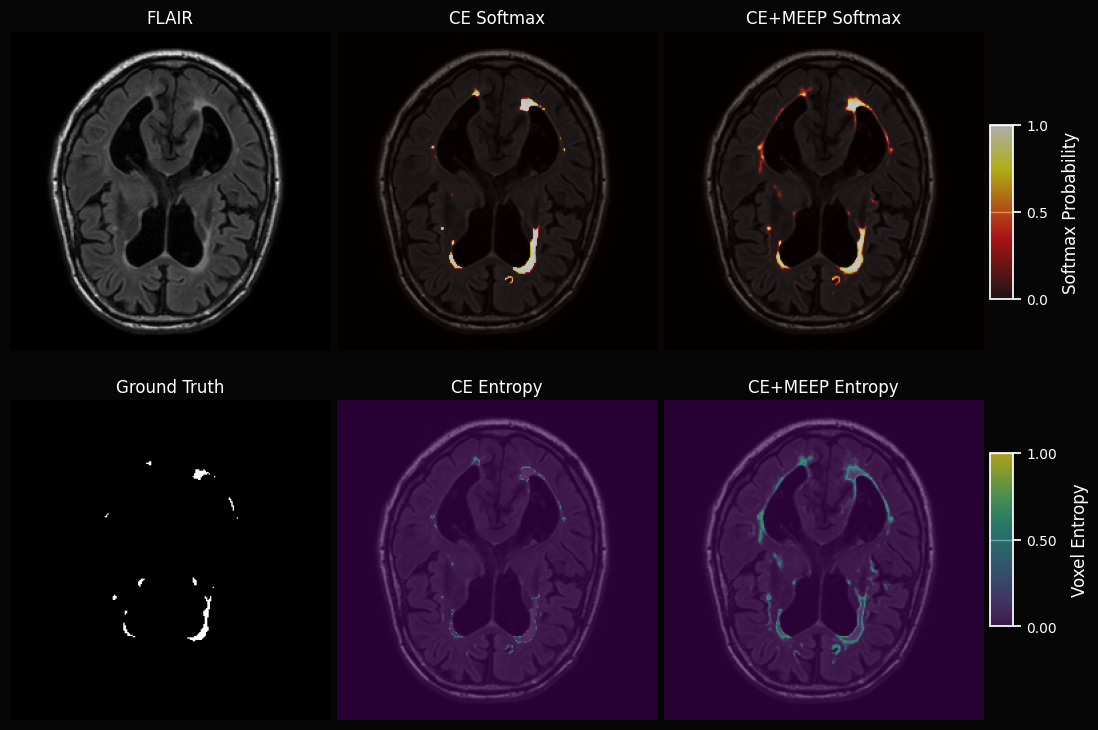

In [15]:
# Code Cell 3: Plotting Figure 2 (Dark Theme, Thinner/Centered Colorbars)
import matplotlib.gridspec as gridspec

# --- Plotting Logic ---
plot_keys_ordered = [
    'FLAIR', 'CE_Prob', 'CE_MEEP_Prob',
    'GT', 'CE_Entropy', 'CE_MEEP_Entropy'
]
titles = [
    'FLAIR', 'CE Softmax', 'CE+MEEP Softmax',
    'Ground Truth', 'CE Entropy', 'CE+MEEP Entropy'
]

# Check if essential data is loaded
if 'FLAIR' not in imgs_fig2:
    print("Figure 2 not generated: FLAIR image is missing.")
else:
    img_data = imgs_fig2['FLAIR']
    if img_data.ndim != 3:
        print(f"Error: FLAIR data is not 3D (shape: {img_data.shape}). Cannot plot slices.")
    else:
        slice_z = img_data.shape[2] // 2 # Axial slice index

        # --- Create Figure and Main GridSpec ---
        fig = plt.figure(figsize=(11.5, 7.5))
        # fig.set_facecolor(FIGURE_FACECOLOR) # Handled by plt.rc

        # Define GridSpec: Adjust last element of width_ratios to make colorbar column thinner
        gs_main = gridspec.GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.07],
                                     wspace=0.1, hspace=0.05) # Adjusted spacing

        axs = [[None for _ in range(3)] for _ in range(2)] # Store main plot axes
        im_prob = None
        im_entropy = None

        # --- Plot Main Images ---
        for i, key in enumerate(plot_keys_ordered):
            row, col = i // 3, i % 3
            ax = fig.add_subplot(gs_main[row, col]) # Use main GridSpec
            axs[row][col] = ax

            if key in imgs_fig2 and isinstance(imgs_fig2[key], np.ndarray) and imgs_fig2[key].ndim == 3:
                if slice_z >= imgs_fig2[key].shape[2]:
                     slice_data_rot = np.zeros_like(imgs_fig2['FLAIR'][:,:,0])
                     ax.text(0.5, 0.5, "Data Invalid\n(Slice Error)", ha='center', va='center', transform=ax.transAxes, color='gray')
                else:
                    slice_data = imgs_fig2[key][:, :, slice_z]
                    slice_data_rot = np.rot90(slice_data, k=1)

                if key == 'FLAIR' or key == 'GT':
                    cmap = 'gray'; vmin, vmax = None, None; alpha = 1.0
                    im = ax.imshow(slice_data_rot, cmap=cmap, vmin=vmin, vmax=vmax, aspect=aspect_axial)
                elif 'Prob' in key:
                    cmap = PROB_CMAP; vmin, vmax = 0, 1; alpha = 0.6
                    flair_slice_rot = np.rot90(imgs_fig2['FLAIR'][:, :, slice_z], k=1)
                    ax.imshow(flair_slice_rot, cmap='gray', aspect=aspect_axial)
                    im = ax.imshow(slice_data_rot, cmap=cmap, vmin=vmin, vmax=vmax, alpha=alpha, aspect=aspect_axial)
                    im_prob = im
                elif 'Entropy' in key:
                    cmap = ENTROPY_CMAP; vmin, vmax = 0, np.log2(2); alpha = 0.6
                    flair_slice_rot = np.rot90(imgs_fig2['FLAIR'][:, :, slice_z], k=1)
                    ax.imshow(flair_slice_rot, cmap='gray', aspect=aspect_axial)
                    im = ax.imshow(slice_data_rot, cmap=cmap, vmin=vmin, vmax=vmax, alpha=alpha, aspect=aspect_axial)
                    im_entropy = im
            else:
                 ax.text(0.5, 0.5, "Data\nNot Found", ha='center', va='center', transform=ax.transAxes, color='gray')

            ax.set_title(titles[i])
            ax.axis('off')

        # --- Add Colorbars using a Nested GridSpec ---
        # Create a nested GridSpec in the last column (now narrower)
        gs_cbar_col = gridspec.GridSpecFromSubplotSpec(7, 1, subplot_spec=gs_main[:, 3], hspace=0.7)

        # Probability colorbar
        if im_prob is not None:
            cax_prob = fig.add_subplot(gs_cbar_col[1:3, 0]) # Span rows 1-2
            cbar_prob = fig.colorbar(im_prob, cax=cax_prob, orientation='vertical')
            cbar_prob.set_label('Softmax Probability', size=MEDIUM_SIZE, color='white', labelpad=10)
            cbar_prob.ax.yaxis.set_tick_params(color='white', labelcolor='white')
            cbar_prob.outline.set_edgecolor('white')
            cbar_prob.set_ticks(np.linspace(0, 1, 3))
        else: print("Skipping probability colorbar.")

        # Entropy colorbar
        if im_entropy is not None:
            cax_entropy = fig.add_subplot(gs_cbar_col[4:6, 0]) # Span rows 4-5
            cbar_entropy = fig.colorbar(im_entropy, cax=cax_entropy, orientation='vertical')
            cbar_entropy.set_label('Voxel Entropy', size=MEDIUM_SIZE, color='white', labelpad=10)
            cbar_entropy.ax.yaxis.set_tick_params(color='white', labelcolor='white')
            cbar_entropy.outline.set_edgecolor('white')
            entropy_ticks = np.linspace(0, np.log2(2), 3)
            cbar_entropy.set_ticks(entropy_ticks)
            cbar_entropy.ax.set_yticklabels([f"{tick:.2f}" for tick in entropy_ticks])
        else: print("Skipping entropy colorbar.")

        # Adjust layout using main GridSpec's tight_layout
        # rect might need adjustment based on the new width ratio
        gs_main.tight_layout(fig, pad=0.5, rect=[0, 0, 0.95, 1]) # Adjusted rect slightly


        # Use the figure_basename defined in Code Cell 2
        save_figure(fig, figure_basename)
        plt.show()